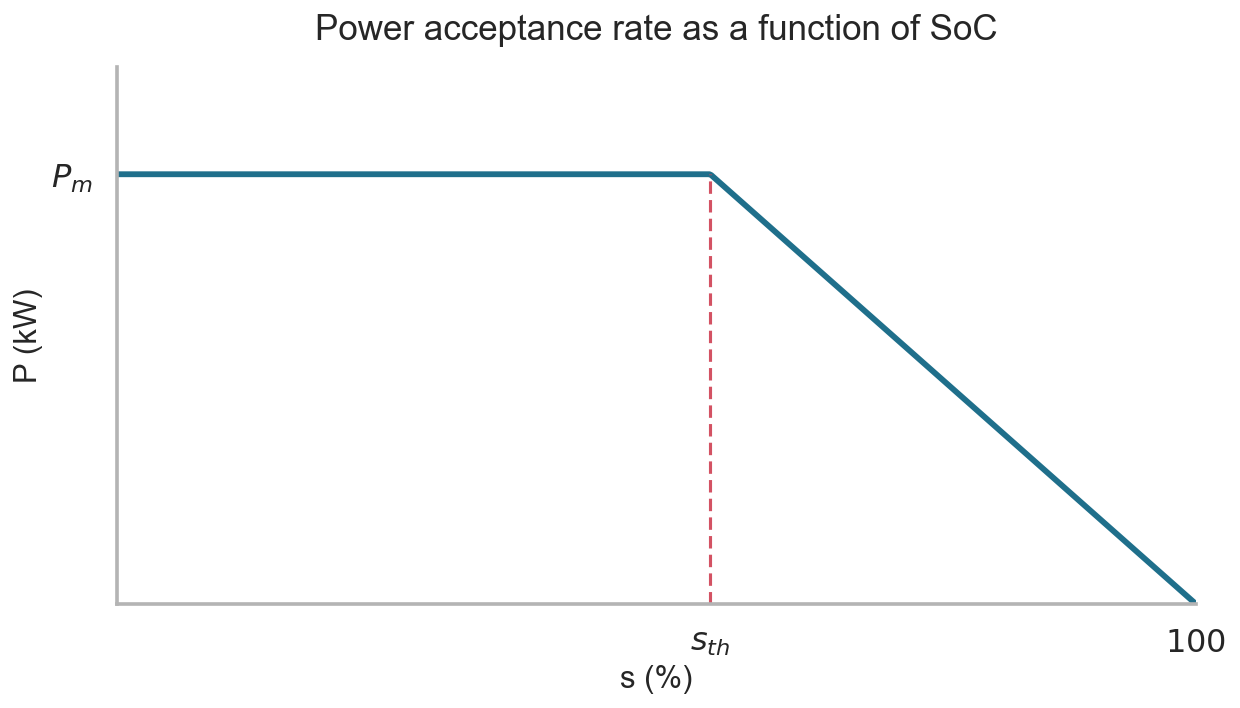

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters (edit as needed)
P_m = 120.0      # kW
s_th = 0.55      # threshold SoC in [0, 1]

# SoC grid in [0, 1]
s = np.linspace(0.0, 1.0, 600)

# Piecewise power acceptance rate:
# P(s) = P_m,                    s <= s_th
# P(s) = P_m * (1 - s)/(1-s_th), s > s_th
P = np.where(s <= s_th, P_m, P_m * (1 - s) / (1 - s_th))

# Minimal Seaborn aesthetics
sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(9.2, 5.4), dpi=140)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

y_max = P_m * 1.25

# Main curve and symbolic reference lines
ax.plot(s * 100, P, color="#1f6f8b", linewidth=3.0, solid_capstyle="round")
ax.axvline(
    s_th * 100,
    ymin=0,
    ymax=P_m / y_max,
    color="#d1495b",
    linestyle=(0, (4, 2)),
    linewidth=1.6,
    alpha=0.95,
)

ax.set_title("Power acceptance rate as a function of SoC", fontsize=18, pad=14, weight="medium")
ax.set_xlabel("s (%)", fontsize=16)
ax.set_ylabel("P (kW)", fontsize=16)

# Keep axes clean and parametric (show only 100 on x-axis)
ax.set_xlim(0, 100)
ax.set_ylim(0, y_max)
ax.set_xticks([s_th * 100, 100])
ax.set_xticklabels([r"$s_{th}$", r"$100$"])
ax.set_yticks([P_m])
ax.set_yticklabels([r"$P_{m}$"])
# Subtle horizontal grid only
#ax.grid(axis="y", color="#e8ecef", linewidth=1.0)
ax.grid(axis="x", visible=False)

# Parametric labels only

# Minimal frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#b4b4b4")
ax.spines["bottom"].set_color("#b4b4b4")

plt.tight_layout()
plt.show()

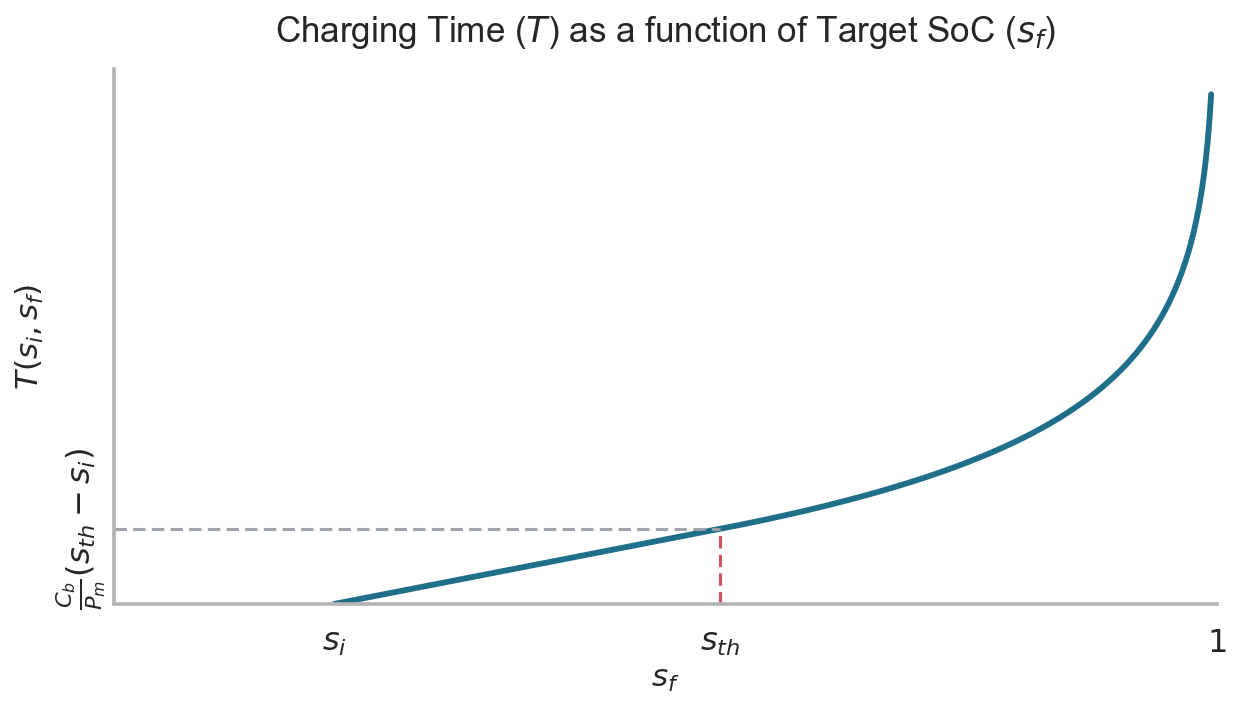

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters (edit as needed)
C_b = 75.0
P_m = 120.0
s_i = 0.2
s_th = 0.55

if not (0 <= s_i < 1 and 0 < s_th < 1):
    raise ValueError("Require 0 <= s_i < 1 and 0 < s_th < 1.")

# Domain for target SoC (must be ahead of initial SoC)
s_f = np.linspace(s_i + 1e-4, 0.995, 700)

# Piecewise charging-time core (inside C_b / P_m):
# 1) s_i < s_f < s_th:         (s_f - s_i)
# 2) s_th < s_i < s_f:         -(1-s_th) * ln((1-s_f)/(1-s_i))
# 3) s_i < s_th < s_f:         (s_th - s_i) - (1-s_th) * ln((1-s_f)/(1-s_th))
core_case1 = s_f - s_i
core_case2 = -(1 - s_th) * np.log((1 - s_f) / (1 - s_i))
core_case3 = (s_th - s_i) - (1 - s_th) * np.log((1 - s_f) / (1 - s_th))

cond_case1 = (s_i < s_f) & (s_f < s_th)
cond_case2 = (s_th < s_i) & (s_i < s_f)
cond_case3 = (s_i < s_th) & (s_th < s_f)

core_T = np.select([cond_case1, cond_case2, cond_case3], [core_case1, core_case2, core_case3], default=np.nan)
T = (C_b / P_m) * core_T

# Value at threshold crossing (used for symbolic y tick/reference line)
T_at_sth = (C_b / P_m) * (s_th - s_i) if s_i < s_th else np.nan

sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(9.2, 5.4), dpi=140)

ax.plot(s_f, T, color="#1f6f8b", linewidth=3)

if s_i < s_th:
    # Draw guides in data coordinates, capped at the threshold crossing.
    ax.vlines(s_th, 0, T_at_sth, color="#d1495b", linestyles=(0, (4, 2)), linewidth=1.6, alpha=0.95)
    ax.hlines(T_at_sth, 0, s_th, color="#9aa0a6", linestyles=(0, (4, 2)), linewidth=1.6, alpha=0.95)

ax.set_title(r"Charging Time ($T$) as a function of Target SoC ($s_{f}$)", fontsize=18, pad=14)
ax.set_xlabel(r"$s_f$", fontsize=16)
ax.set_ylabel(r"$T(s_i, s_f)$", fontsize=16)

# Force both axes to start from zero
ax.set_xlim(left=0, right=1)
ax.set_ylim(bottom=0)

# Remove numeric ticks and keep only parametric labels
if s_i < s_th:
    ax.set_xticks([s_i, s_th, 1.0])
    ax.set_xticklabels([r"$s_i$", r"$s_{th}$", r"$1$"])
    ax.set_yticks([T_at_sth])
    ax.set_yticklabels([r"$\frac{C_b}{P_m}(s_{th}-s_i)$"])
else:
    ax.set_xticks([s_i, 1.0])
    ax.set_xticklabels([r"$s_i$", r"$1$"])
    ax.set_yticks([])

ax.tick_params(axis="y", labelrotation=90, pad=8)
for label in ax.get_yticklabels():
    label.set_verticalalignment("center")
    label.set_horizontalalignment("center")
    label.set_rotation_mode("anchor")

#ax.grid(axis="y", color="#e8ecef", linewidth=1.0)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#b4b4b4")
ax.spines["bottom"].set_color("#b4b4b4")

plt.tight_layout()
plt.show()

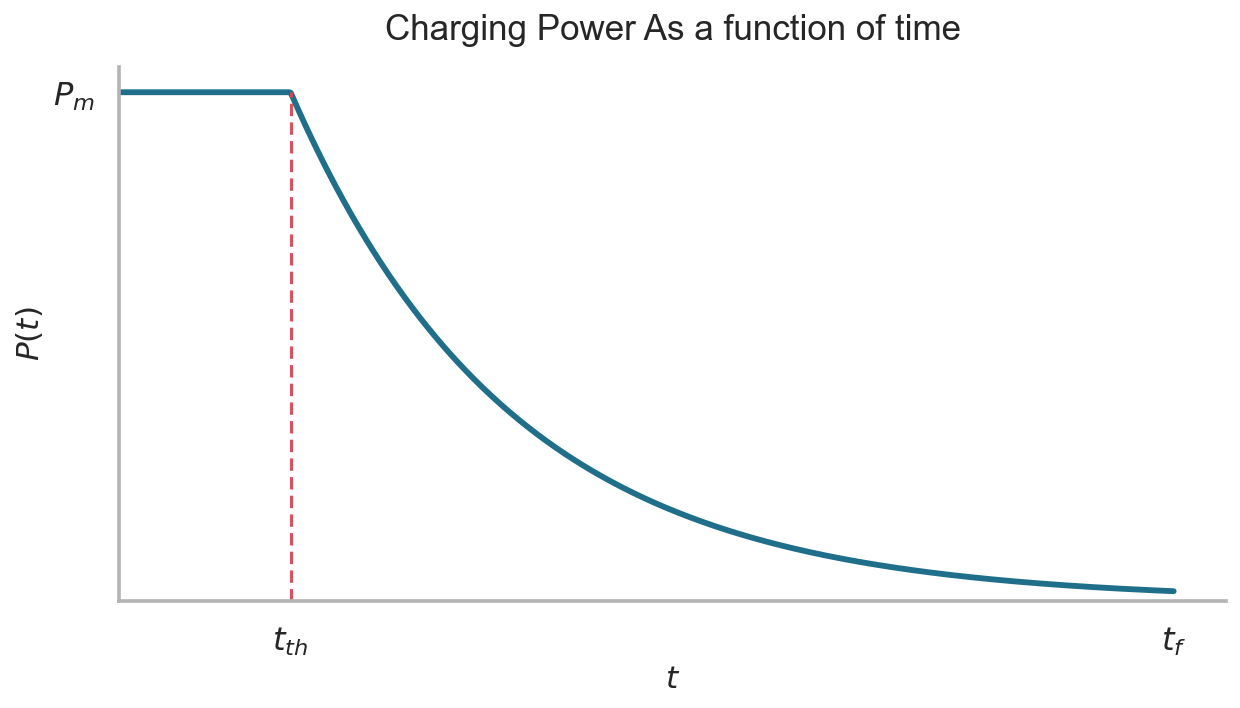

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters (edit as needed)
C_b = 75.0
P_m = 120.0
s_i = 0.2
s_th = 0.55

if not (0 <= s_i < s_th < 1):
    raise ValueError("Require 0 <= s_i < s_th < 1.")

# Threshold time from the given relation
t_th = (C_b / P_m) * (s_th - s_i)

# Time horizon for visualization (post-threshold decay)
t_f = t_th + 4.0 * (C_b * (1 - s_th) / P_m)
t = np.linspace(0.0, t_f, 700)

# P(t): constant at P_m before threshold, then exponential decay after threshold
P_t = np.full_like(t, P_m)
mask = t >= t_th
P_t[mask] = P_m * np.exp(-(P_m / (C_b * (1 - s_th))) * (t[mask] - t_th))

sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(9.2, 5.4), dpi=140)

ax.plot(t, P_t, color="#1f6f8b", linewidth=3)
ax.vlines(t_th, 0, P_m, color="#d1495b", linestyles=(0, (4, 2)), linewidth=1.6, alpha=0.95)

ax.set_title("Charging Power As a function of time", fontsize=18, pad=14)
ax.set_xlabel(r"$t$", fontsize=16)
ax.set_ylabel(r"$P(t)$", fontsize=16)

# Same labeling rule: symbolic ticks only
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xticks([t_th, t_f])
ax.set_xticklabels([r"$t_{th}$", r"$t_f$"])
ax.set_yticks([P_m])
ax.set_yticklabels([r"$P_m$"])

#ax.grid(axis="y", color="#e8ecef", linewidth=1.0)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#b4b4b4")
ax.spines["bottom"].set_color("#b4b4b4")

plt.tight_layout()
plt.show()